In [54]:
import astropy
import numpy as np
from pathlib import Path
from astropy.nddata import CCDData
from astropy.io import fits
import astropy.units as u
import matplotlib.pyplot as plt
import warnings
import glob
import math

In [4]:
#PIC = fits.util.get_testdata_filepath('data/LOPS2PICtarget2.1.0.1-t-fg-c-scv.fits')
PIC = fits.open('data/LOPS2PICtarget2.1.0.1-t-fg-c-scv.fits') #see group projects canvas page
#headers = np.asarray(PIC[1].header)
data = np.asarray(PIC[1].data)
print(f"{len(data["PICid"])} entries")

309787 entries


In [5]:
myepictable = []

for i in range(len(data["Mass"])):
    if data["Mass"][i] < 1.5:
        myepictable.append(data[i])

data_reduced = np.asarray(myepictable)

In [6]:
print(f"{data_reduced["Mass"][0]} solar masses, {data_reduced["Radius"][0]} solar radii, {data_reduced["Teff"][0]} K")

0.553082617452391 solar masses, 0.528597868558916 solar radii, 3706.57015580926 K


In [206]:
#M = data_reduced["Mass"] #grabs the masses of the relevent stars in PIC, in solar masses
#R = data_reduced["Radius"] #grabs the radii of the relevent stars in PIC, in solar radii
#T = data_reduced["Teff"] #grabs the temperatures of the relevent stars in PIC, in Kelvin
#solar mass = 1.989 × 10^30 kg
#solar radius = 696,340 km
#solar temp = 5778 K

def max_freq(M, R, T):
    solar_temp = 5778
    dT = T / solar_temp
    return( float(M * R**(-2) * dT**(-0.5)) ) #returns max frequency in terms of max frequency of the Sun

def tau_gran(M, R, T):
    tau_gran_sun = 250 #characteristic timescale of granulation for the Sun
    return( float( ( max_freq(M, R, T) )**(-1) * tau_gran_sun) ) #returns the characteristic timescale of granulation for the star

def lumin(M, R, T):    
    solar_lum = 3.828 * 10**26
    solar_temp = 5772
    return( float(R**2 * (T / solar_temp)**4) ) #returns luminosity 

def granulation_amplitude(M, R, T):
    #max_freq_sun = 3090
    granulation_amplitude_sun = 20 #currently unknown, ask about
    return( float(granulation_amplitude_sun * (lumin(M, R, T)**2 * max_freq(M, R, T)) / (M**3 * (T / 5778)**5.5)) ) #1.989*10**30, 3.828 * 10**26

def power_spec_granulation(M, R, T, freq):
    return( (4 * granulation_amplitude(M, R, T)**2 * 10**-6 * tau_gran(M, R, T) ) / (1 + (2 * np.pi * freq * 10**-6 * tau_gran(M, R, T))**4 ) )

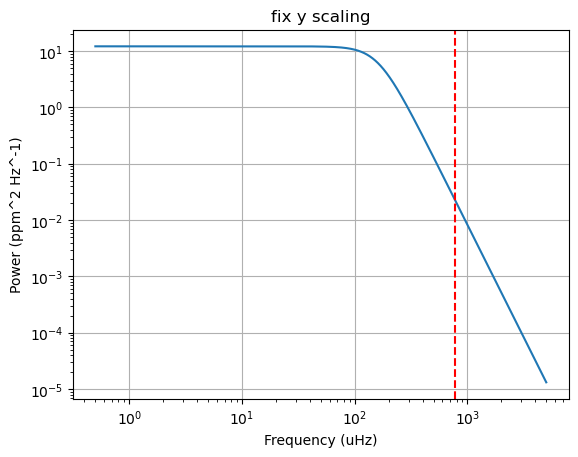

In [207]:
f = np.linspace(5*10**-1, 5*10**3, 100000)
star_input = 3
P = power_spec_granulation(data_reduced["Mass"][star_input], data_reduced["Radius"][star_input], data_reduced["Teff"][star_input], f)
#P = power_spec_granulation(1.223, 1.357, 6325, f)

#print( max_freq(1.223, 1.357, 6325) )
#print( granulation_amplitude(1.223, 1.357, 6325) )
#print( lumin(1.223, 1.357, 6325) )

#for i in range(0, len(P)):
#    P[i] += 0.5 #meant to represent the shot noise

plt.loglog(f, P)
plt.axvline(3090 * max_freq(data_reduced["Mass"][star_input], data_reduced["Radius"][star_input], data_reduced["Teff"][star_input]), ls='--', color='r') #multiplied by max freq of sun (3090 uHz) as its a ratio
plt.grid(which='major')
plt.title("fix y scaling")
#plt.xlim(0, 1000)
ylim = power_spec_granulation(data_reduced["Mass"][star_input], data_reduced["Radius"][star_input], data_reduced["Teff"][star_input], 0) #used for the ylim below
#plt.ylim(ylim * 10**-4, ylim * 3)
plt.ylabel("Power (ppm^2 Hz^-1)")
plt.xlabel("Frequency (uHz)")
plt.show()